In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv("../data/cleaned_data.csv")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

display(df.head())

Dataset shape: (720, 6)
First date: 2023-01-12 00:00:00
Last date: 2025-12-21 00:00:00


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-22,32.0,49.0,39.0,"7,122",227.0
2,2023-01-23,32.0,50.0,39.0,"7,280",181.0
3,2023-01-24,47.0,42.0,47.0,"7,433",175.0
4,2023-01-25,20.0,22.0,41.0,"7,538",180.0


In [2]:
# Select the target variable

target = "Children in HHS Care"

# Create a time-series dataset
ts = df[["Date", target]].copy()

# Set Date as the index
ts = ts.set_index("Date")

print("Target variable:", target)
print("Time-series shape:", ts.shape)

display(ts.head())

Target variable: Children in HHS Care
Time-series shape: (720, 1)


,Children in HHS Care
Date,
2023-01-12,"6,566"
2023-01-22,"7,122"
2023-01-23,"7,280"
2023-01-24,"7,433"
2023-01-25,"7,538"


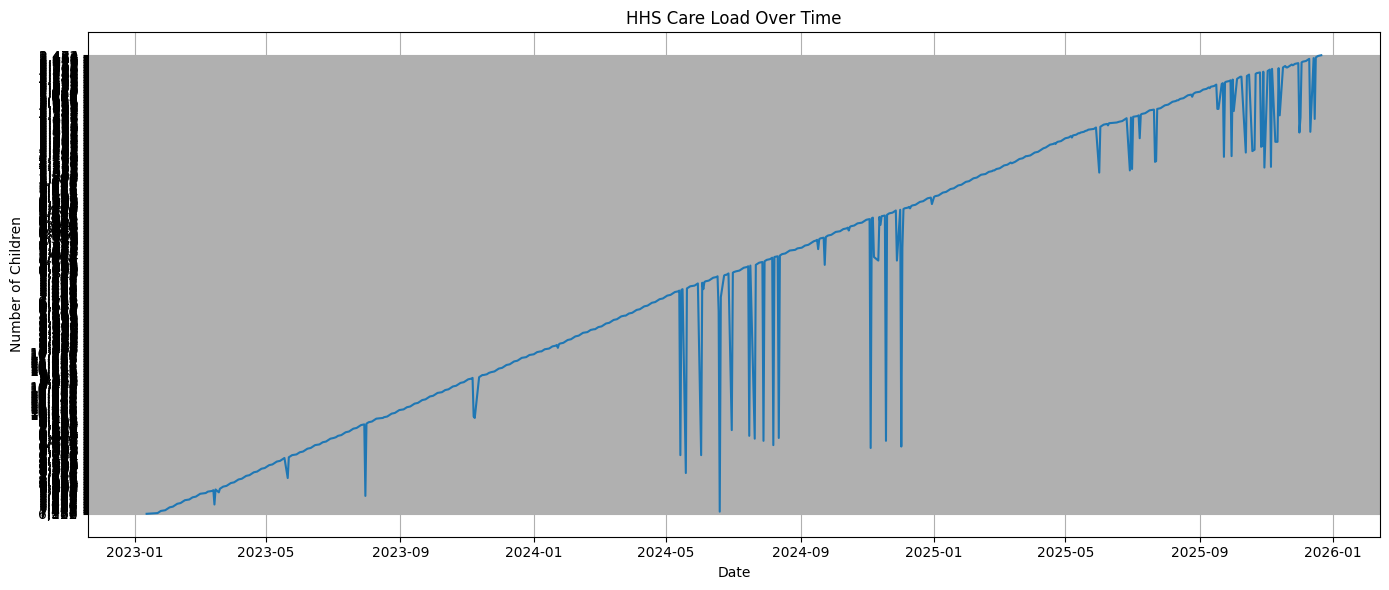

In [3]:
# Plot HHS Care load over time

plt.figure(figsize=(14, 6))

plt.plot(ts.index, ts[target])

plt.title("HHS Care Load Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
# Split the time-series data into training and testing sets

train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training data shape: (576, 1)
Testing data shape: (144, 1)

Training period:
2023-01-12 00:00:00 to 2025-05-13 00:00:00

Testing period:
2025-05-14 00:00:00 to 2025-12-21 00:00:00


In [23]:
# Step 4: Train Linear Regression using date index

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Make copies
train_model = train.copy()
test_model = test.copy()

# Convert target values to numeric
# First remove commas
train_model["Children in HHS Care"] = (
    train_model["Children in HHS Care"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

test_model["Children in HHS Care"] = (
    test_model["Children in HHS Care"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

# Convert index to datetime
train_model.index = pd.to_datetime(train_model.index)
test_model.index = pd.to_datetime(test_model.index)

# Create number of days from first training date
start_date = train_model.index.min()

X_train = (
    train_model.index - start_date
).days.values.reshape(-1, 1)

X_test = (
    test_model.index - start_date
).days.values.reshape(-1, 1)

# Target values
y_train = train_model["Children in HHS Care"].values
y_test = test_model["Children in HHS Care"].values

# Check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("\nModel trained successfully!")
print("Number of predictions:", len(y_pred))

X_train shape: (576, 1)
y_train shape: (576,)
X_test shape: (144, 1)
y_test shape: (144,)

Model trained successfully!
Number of predictions: 144


In [19]:
# Step 5: Evaluate the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

print("\ny_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

Model Evaluation
-----------------
MAE : 1179.7157116027854
MSE : 1593159.5518013702
RMSE: 1262.20424329875
R² Score: -50.54053047275001

y_test shape: (144,)
y_pred shape: (144,)


In [25]:
print("Actual vs Predicted:")

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head(20))

Actual vs Predicted:
    Actual    Predicted
0   2394.0  4200.265244
1   2410.0  4193.539073
2   2437.0  4173.360562
3   2457.0  4166.634391
4   2467.0  4153.182050
5   2473.0  4146.455880
6   2504.0  4112.825027
7   2499.0  4106.098857
8   2506.0  4099.372686
9   2528.0  4079.194175
10  2518.0  4072.468004
11  2519.0  4065.741834
12  2516.0  4059.015663
13  2503.0  4052.289493
14  2507.0  4032.110981
15  2516.0  4025.384811
16  2511.0  4018.658640
17  2523.0  3971.575447
18  2501.0  3958.123106
19  2508.0  3937.944594


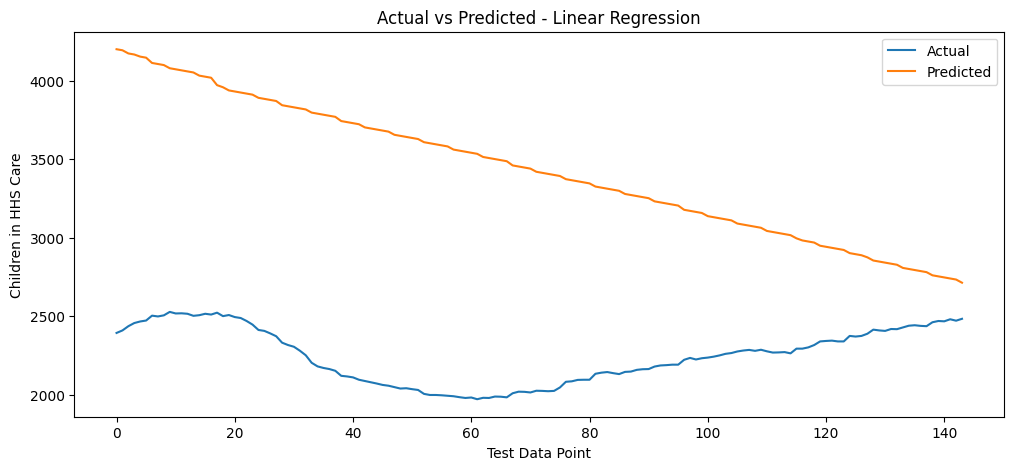

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Actual vs Predicted - Linear Regression")
plt.xlabel("Test Data Point")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.show()

In [24]:
print("Training target:")
print(y_train[:10])
print("Training minimum:", y_train.min())
print("Training maximum:", y_train.max())
print("Training mean:", y_train.mean())

print("\nTesting target:")
print(y_test[:10])
print("Testing minimum:", y_test.min())
print("Testing maximum:", y_test.max())
print("Testing mean:", y_test.mean())

Training target:
[6566. 7122. 7280. 7433. 7538. 7472. 7743. 7803. 7903. 7879.]
Training minimum: 2109.0
Training maximum: 11516.0
Training mean: 7014.081597222223

Testing target:
[2394. 2410. 2437. 2457. 2467. 2473. 2504. 2499. 2506. 2528.]
Testing minimum: 1972.0
Testing maximum: 2528.0
Testing mean: 2250.0486111111113


In [13]:
print("TEST DATA SHAPE:", test.shape)

print("\nTest target column:")
print(test["Children in HHS Care"].head(20))

print("\nTest target data type:")
print(test["Children in HHS Care"].dtype)

print("\nNumber of values:")
print(test["Children in HHS Care"].notna().sum())

TEST DATA SHAPE: (144, 1)

Test target column:
Date
2025-05-14    2,394
2025-05-15    2,410
2025-05-18    2,437
2025-05-19    2,457
2025-05-21    2,467
2025-05-22    2,473
2025-05-27    2,504
2025-05-28    2,499
2025-05-29    2,506
2025-06-01    2,528
2025-06-02    2,518
2025-06-03    2,519
2025-06-04    2,516
2025-06-05    2,503
2025-06-08    2,507
2025-06-09    2,516
2025-06-10    2,511
2025-06-17    2,523
2025-06-19    2,501
2025-06-22    2,508
Name: Children in HHS Care, dtype: str

Test target data type:
str

Number of values:
144


In [31]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# Convert target column from string to numeric
train["Children in HHS Care"] = (
    train["Children in HHS Care"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

test["Children in HHS Care"] = (
    test["Children in HHS Care"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

# Create date features
def create_features(df):
    X = pd.DataFrame(index=df.index)

    dates = pd.to_datetime(df.index)

    X["year"] = dates.year
    X["month"] = dates.month
    X["day"] = dates.day
    X["dayofweek"] = dates.dayofweek
    X["dayofyear"] = dates.dayofyear

    return X

# Create X and y
X_train = create_features(train)
X_test = create_features(test)

y_train = train["Children in HHS Care"]
y_test = test["Children in HHS Care"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Create Random Forest model
model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
model_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = model_rf.predict(X_test)

print("\nRandom Forest model trained successfully!")
print("Number of predictions:", len(y_pred_rf))

X_train shape: (576, 5)
X_test shape: (144, 5)
y_train shape: (576,)
y_test shape: (144,)

Random Forest model trained successfully!
Number of predictions: 144


In [30]:
print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE:", test.shape)

print("\nTRAIN COLUMNS:")
print(train.columns)

print("\nTEST COLUMNS:")
print(test.columns)

print("\nTRAIN HEAD:")
print(train.head())

print("\nTEST HEAD:")
print(test.head())

TRAIN SHAPE: (576, 1)
TEST SHAPE: (144, 1)

TRAIN COLUMNS:
Index(['Children in HHS Care'], dtype='str')

TEST COLUMNS:
Index(['Children in HHS Care'], dtype='str')

TRAIN HEAD:
           Children in HHS Care
Date                           
2023-01-12                6,566
2023-01-22                7,122
2023-01-23                7,280
2023-01-24                7,433
2023-01-25                7,538

TEST HEAD:
           Children in HHS Care
Date                           
2025-05-14                2,394
2025-05-15                2,410
2025-05-18                2,437
2025-05-19                2,457
2025-05-21                2,467


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Evaluation:
MAE: 182.40423611111112
MSE: 48686.870020486116
RMSE: 220.65101409349134
R² Score: -0.5750758328482473


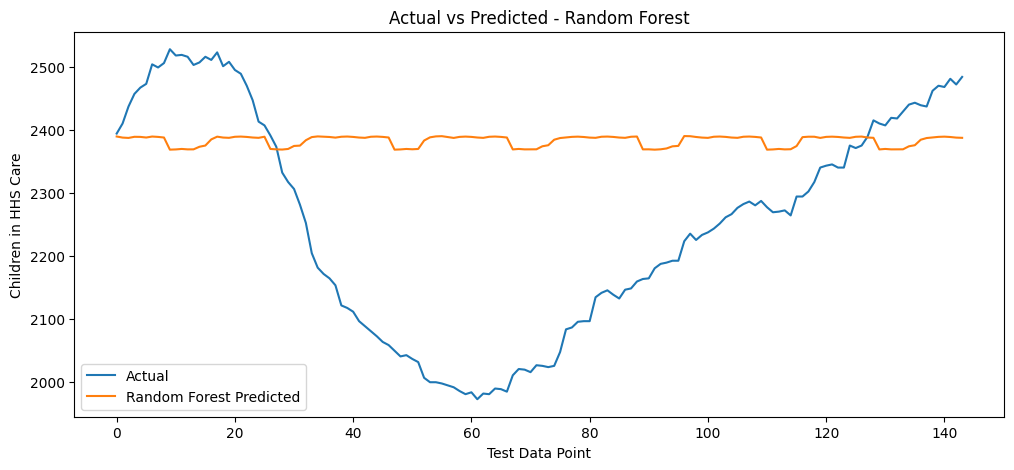

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Random Forest Predicted")

plt.title("Actual vs Predicted - Random Forest")
plt.xlabel("Test Data Point")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.show()

In [34]:
print("MODEL COMPARISON")
print("----------------")

print("\nLinear Regression:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

print("\nRandom Forest:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MODEL COMPARISON
----------------

Linear Regression:
MAE: 1179.7157116027854
RMSE: 1262.20424329875
R² Score: -50.54053047275001

Random Forest:
MAE: 182.40423611111112
RMSE: 220.65101409349134
R² Score: -0.5750758328482473


In [36]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
     Feature  Importance
0       year    0.682628
4  dayofyear    0.279483
1      month    0.033299
2        day    0.004078
3  dayofweek    0.000512


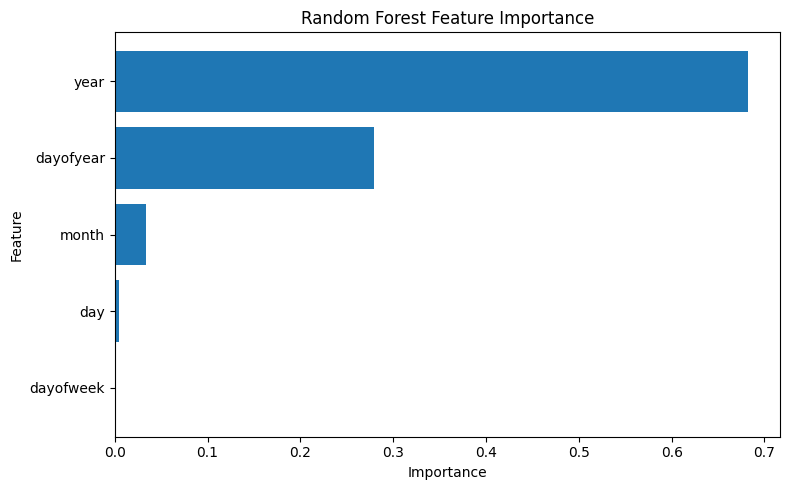

In [37]:
# Plot Random Forest Feature Importance

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [38]:
print("FINAL MODEL SUMMARY")
print("-------------------")

print("Best Model: Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

print("\nMost Important Features:")
print(feature_importance)

FINAL MODEL SUMMARY
-------------------
Best Model: Random Forest
MAE: 182.40423611111112
RMSE: 220.65101409349134
R² Score: -0.5750758328482473

Most Important Features:
     Feature  Importance
0       year    0.682628
4  dayofyear    0.279483
1      month    0.033299
2        day    0.004078
3  dayofweek    0.000512


In [45]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    model_rf,
    "models/random_forest_hhs_care_model.pkl"
)

print("Random Forest model saved successfully!")
print("Saved at: models/random_forest_hhs_care_model.pkl")

Random Forest model saved successfully!
Saved at: models/random_forest_hhs_care_model.pkl


In [43]:
# Step 14: Future Prediction

import pandas as pd

# Enter future dates
future_dates = pd.to_datetime([
    "2026-01-01",
    "2026-02-01",
    "2026-03-01",
    "2026-04-01",
    "2026-05-01"
])

# Create features from future dates
future_data = pd.DataFrame({
    "year": future_dates.year,
    "month": future_dates.month,
    "day": future_dates.day,
    "dayofweek": future_dates.dayofweek,
    "dayofyear": future_dates.dayofyear
})

# Make predictions
future_predictions = model_rf.predict(future_data)

# Display results
future_results = pd.DataFrame({
    "Date": future_dates,
    "Predicted Children in HHS Care": future_predictions
})

print("FUTURE PREDICTIONS")
print("------------------")
print(future_results)

FUTURE PREDICTIONS
------------------
        Date  Predicted Children in HHS Care
0 2026-01-01                         6272.48
1 2026-02-01                         3673.69
2 2026-03-01                         2300.32
3 2026-04-01                         2204.29
4 2026-05-01                         2306.81
